## Exercise 13: EDA on `hr_employee_data.xlsx`

**Task (from the book's exercise sheet):** "The dataset 'hr_employee_data.xlsx' contains
data related to a company's employees. Carry out an EDA and accompanying analysis,
imagining that the company's leadership team will review the analysis. In this exercise,
no ML modeling should be done (that will be done in the next chapter). 

Below is a complete EDA (exploratory data analysis) - **with no ML modeling** - on the
real dataset, with a summary analysis written for a leadership audience at the end.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
df = pd.read_excel('hr_employee_data.xlsx')
df

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,IND02438,0.38,0.53,2,157,3,0,1,0,sales,low
1,IND28133,0.80,0.86,5,262,6,0,1,0,sales,medium
2,IND07164,0.11,0.88,7,272,4,0,1,0,sales,medium
3,IND30478,0.72,0.87,5,223,5,0,1,0,sales,low
4,IND24003,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...,...
14994,IND40221,0.40,0.57,2,151,3,0,1,0,support,low
14995,IND24196,0.37,0.48,2,160,3,0,1,0,support,low
14996,IND33544,0.37,0.53,2,143,3,0,1,0,support,low
14997,IND40533,0.11,0.96,6,280,4,0,1,0,support,low


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp_Id                 14999 non-null  str    
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_montly_hours   14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   left                   14999 non-null  int64  
 8   promotion_last_5years  14999 non-null  int64  
 9   Department             14999 non-null  str    
 10  salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(3)
memory usage: 1.3 MB


In [9]:
print("Missing values per column:")
print(df.isna().sum())
print("\nNumber of duplicate rows:", df.duplicated().sum())
print("\nNumber of unique Emp_Id vs. number of rows:", df["Emp_Id"].nunique(), "vs", df.shape[0])

Missing values per column:
Emp_Id                   0
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

Number of duplicate rows: 0

Number of unique Emp_Id vs. number of rows: 14999 vs 14999


The dataset is complete - no missing values and no duplicates - and `Emp_Id` is a
unique identifier per row (one row per employee). The dataset contains **14,999
employees** and 11 columns: `satisfaction_level` (self-reported satisfaction, 0-1),
`last_evaluation` (latest performance score, 0-1), `number_project` (number of projects),
`average_montly_hours` (average monthly working hours), `time_spend_company` (years at
the company), `Work_accident` (whether the person has had a workplace accident), `left`
(whether the person has left - the **target variable** for next chapter's ML modeling),
`promotion_last_5years` (whether the person was promoted in the last 5 years), and
`Department` and `salary` (salary level: low/medium/high).

In [10]:
df.describe()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Employee attrition - the overall picture

Share of employees who have left: 23.8%


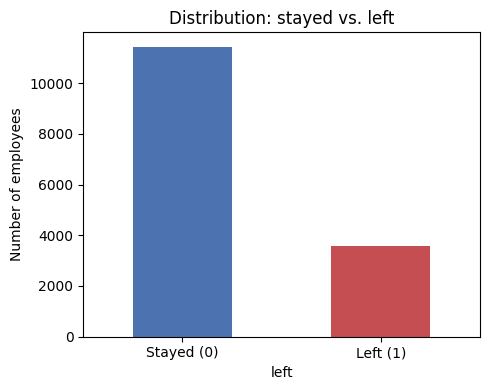

In [11]:
attrition_rate = df["left"].mean()
print(f"Share of employees who have left: {attrition_rate:.1%}")

fig, ax = plt.subplots(figsize=(5, 4))
df["left"].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Stayed (0)", "Left (1)"], rotation=0)
ax.set_ylabel("Number of employees")
ax.set_title("Distribution: stayed vs. left")
plt.tight_layout()
plt.show()


Nearly **24%** of the employees in the dataset have left. That's a high share and
justifies a deeper look into *why*.

### Satisfaction level - the single strongest signal

In [12]:
corr_with_left = df[[
    "satisfaction_level", "last_evaluation", "number_project",
    "average_montly_hours", "time_spend_company", "Work_accident",
    "promotion_last_5years", "left",
]].corr()["left"].sort_values()
print(corr_with_left)


satisfaction_level      -0.388375
Work_accident           -0.154622
promotion_last_5years   -0.061788
last_evaluation          0.006567
number_project           0.023787
average_montly_hours     0.071287
time_spend_company       0.144822
left                     1.000000
Name: left, dtype: float64


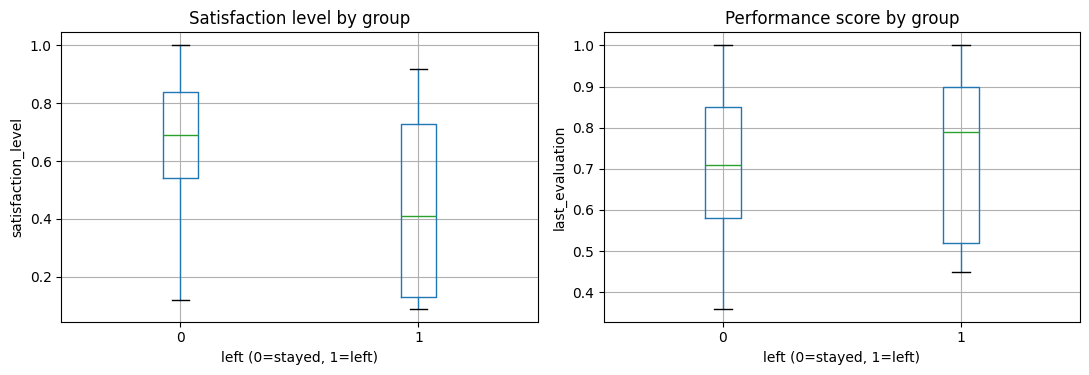

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df.boxplot(column="satisfaction_level", by="left", ax=axes[0])
axes[0].set_xlabel("left (0=stayed, 1=left)")
axes[0].set_ylabel("satisfaction_level")
axes[0].set_title("Satisfaction level by group")

df.boxplot(column="last_evaluation", by="left", ax=axes[1])
axes[1].set_xlabel("left (0=stayed, 1=left)")
axes[1].set_ylabel("last_evaluation")
axes[1].set_title("Performance score by group")

plt.suptitle("")
plt.tight_layout()
plt.show()


Satisfaction level (`satisfaction_level`) has by far the strongest correlation with
`left` (about **-0.39**) of all the numeric variables - employees who leave report
noticeably lower satisfaction on average. The performance score (`last_evaluation`), on
the other hand, is essentially identical on average between the two groups (0.715 vs.
0.718) - but the boxplot reveals a much wider spread among those who left, which is
explored further below.

### The three clusters of employees who leave

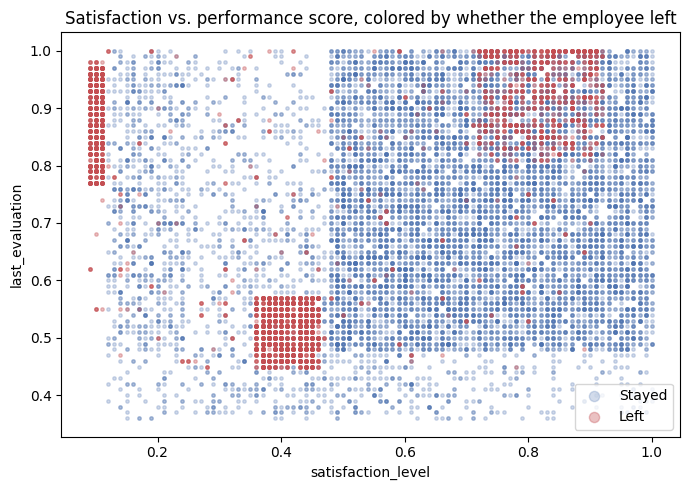

In [15]:
left_df = df[df["left"] == 1]
stayed_df = df[df["left"] == 0]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(stayed_df["satisfaction_level"], stayed_df["last_evaluation"],
           s=6, alpha=0.25, color="#4C72B0", label="Stayed")
ax.scatter(left_df["satisfaction_level"], left_df["last_evaluation"],
           s=6, alpha=0.35, color="#C44E52", label="Left")
ax.set_xlabel("satisfaction_level")
ax.set_ylabel("last_evaluation")
ax.set_title("Satisfaction vs. performance score, colored by whether the employee left")
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()


The scatter plot shows that the employees who left (red) are not one uniform group
but form distinct **clusters**: (1) low satisfaction + low performance score (likely
dissatisfied low performers), (2) low-to-medium satisfaction + high performance score
(possibly overworked high performers who are still dissatisfied), and (3) high
satisfaction + high performance score (harder to explain without more context, but
possibly people who left for new opportunities despite being happy). This is an important
insight for leadership: **there are likely several different reasons people leave**, not
just one - a single, generic "raise satisfaction" initiative is unlikely to work for all
of these groups.

### Salary and promotion

In [16]:
salary_attrition = df.groupby("salary")["left"].mean().reindex(["low", "medium", "high"])
promo_attrition = df.groupby("promotion_last_5years")["left"].mean()
accident_attrition = df.groupby("Work_accident")["left"].mean()

print("Share who left, by salary level:\n", salary_attrition, "\n")
print("Share who left, by promotion in the last 5 years:\n", promo_attrition, "\n")
print("Share who left, by workplace accident:\n", accident_attrition)


Share who left, by salary level:
 salary
low       0.296884
medium    0.204313
high      0.066289
Name: left, dtype: float64 

Share who left, by promotion in the last 5 years:
 promotion_last_5years
0    0.241962
1    0.059561
Name: left, dtype: float64 

Share who left, by workplace accident:
 Work_accident
0    0.265160
1    0.077916
Name: left, dtype: float64


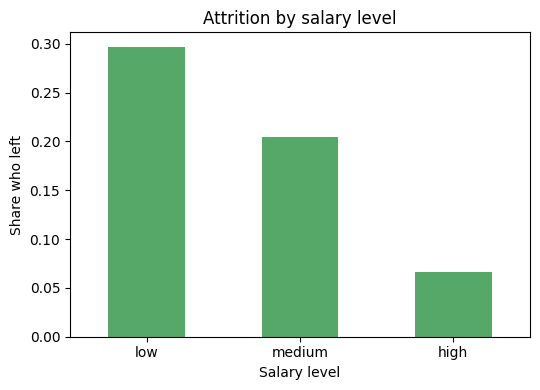

In [17]:
fig, ax = plt.subplots(figsize=(5.5, 4))
salary_attrition.plot(kind="bar", ax=ax, color="#55A868")
ax.set_ylabel("Share who left")
ax.set_xlabel("Salary level")
ax.set_title("Attrition by salary level")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


A clear pattern: the lower the salary, the higher the attrition (**29.7%** for low
salary vs. only **6.6%** for high salary). Employees promoted in the last 5 years leave
much less often (**6.0%** vs. **24.2%** for those not promoted), and the same pattern
holds for workplace accidents (7.8% vs. 26.5% - likely because employees who had an
accident have, in higher proportion, already been with the company longer, or it is an
indirect signal of tenure/role type).

### Department

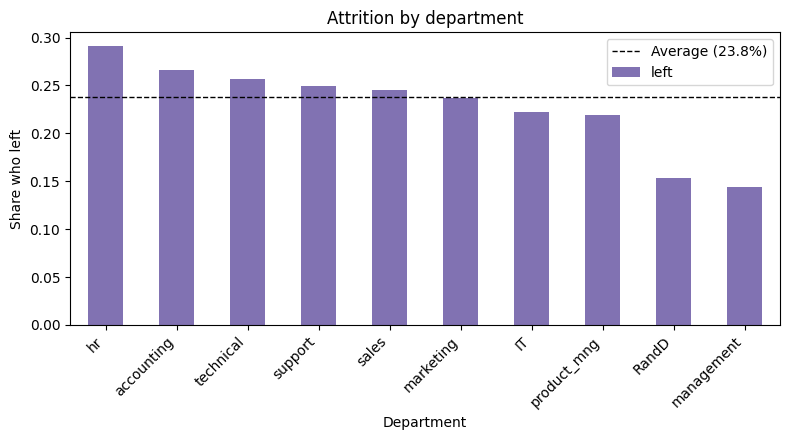

In [18]:
dept_attrition = df.groupby("Department")["left"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4.5))
dept_attrition.plot(kind="bar", ax=ax, color="#8172B2")
ax.axhline(attrition_rate, color="black", linestyle="--", linewidth=1, label=f"Average ({attrition_rate:.1%})")
ax.set_ylabel("Share who left")
ax.set_xlabel("Department")
ax.set_title("Attrition by department")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


The HR department has the highest attrition (**29.1%**), followed by accounting
and technical, while management and R&D have the lowest (14-15%) - likely linked to
higher average pay and more promotion opportunities in those roles.

### Workload: number of projects and working hours

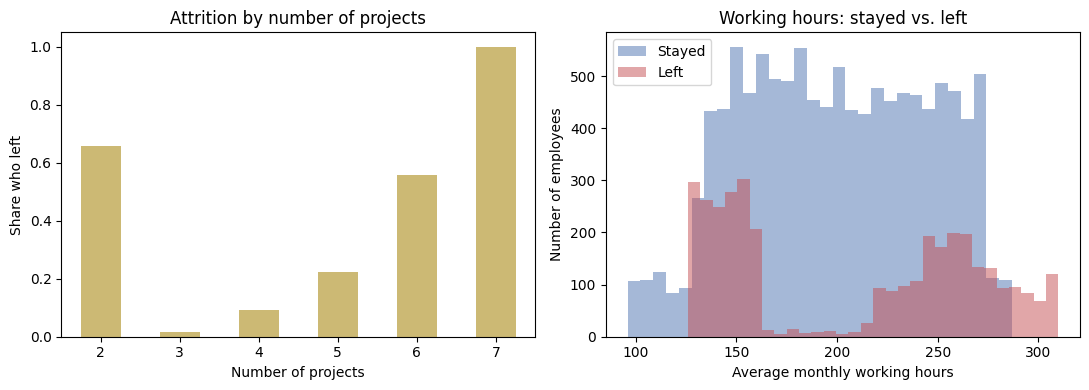

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

proj_attrition = df.groupby("number_project")["left"].mean()
proj_attrition.plot(kind="bar", ax=axes[0], color="#CCB974")
axes[0].set_xlabel("Number of projects")
axes[0].set_ylabel("Share who left")
axes[0].set_title("Attrition by number of projects")
axes[0].tick_params(axis="x", rotation=0)

axes[1].hist(stayed_df["average_montly_hours"], bins=30, alpha=0.5, label="Stayed", color="#4C72B0")
axes[1].hist(left_df["average_montly_hours"], bins=30, alpha=0.5, label="Left", color="#C44E52")
axes[1].set_xlabel("Average monthly working hours")
axes[1].set_ylabel("Number of employees")
axes[1].set_title("Working hours: stayed vs. left")
axes[1].legend()

plt.tight_layout()
plt.show()

A clear U-shaped pattern: employees with **very few** (2) or **very many** (6-7)
projects leave at a much higher rate than those with a "normal" number (3-5) of projects.
The working-hours histogram shows the same tendency toward bimodality as the
satisfaction/evaluation scatter above: one group of employees who left works fewer hours
than average (likely underutilized/dissatisfied) and another group works considerably
more hours than average (likely overworked/burned out) - while employees who stay are
more concentrated around a "normal" range (roughly 150-250 h/month).

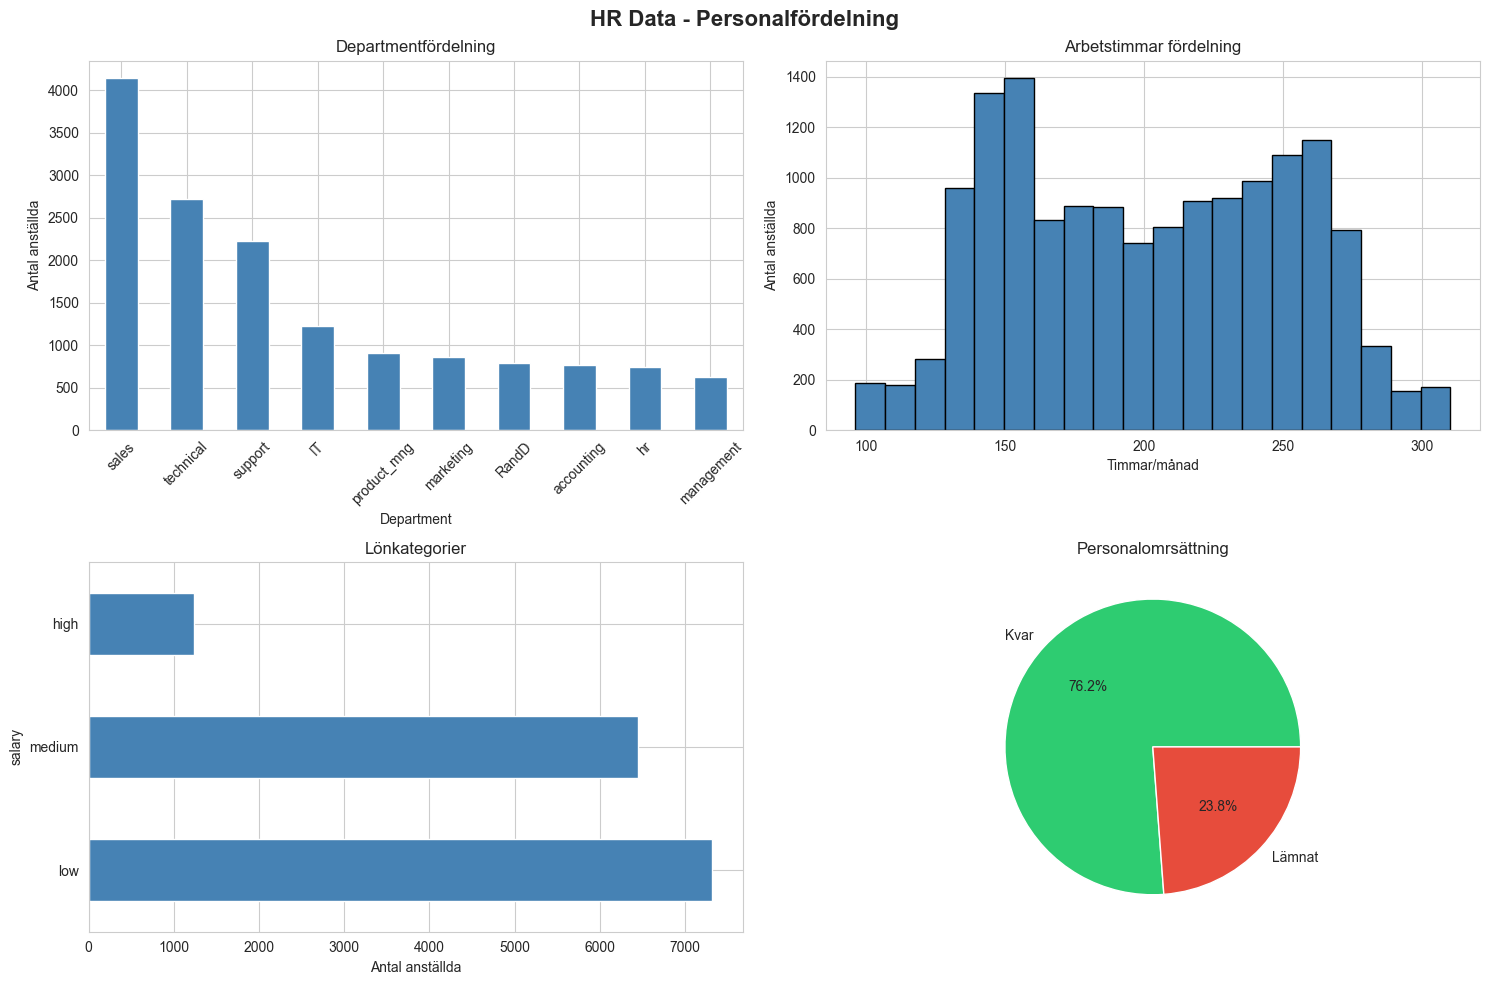

Grafer skapade


In [20]:
# Sätt style för grafer
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 12)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('HR Data - Personalfördelning', fontsize=16, fontweight='bold')

# Department
if 'Department' in df.columns:
    df['Department'].value_counts().plot(kind='bar', ax=axes[0, 0], color='steelblue')
    axes[0, 0].set_title('Departmentfördelning')
    axes[0, 0].set_xlabel('Department')
    axes[0, 0].set_ylabel('Antal anställda')
    axes[0, 0].tick_params(axis='x', rotation=45)

# Arbetstimmar fördelning
if 'average_montly_hours' in df.columns:
    axes[0, 1].hist(df['average_montly_hours'], bins=20, color='steelblue', edgecolor='black')
    axes[0, 1].set_title('Arbetstimmar fördelning')
    axes[0, 1].set_xlabel('Timmar/månad')
    axes[0, 1].set_ylabel('Antal anställda')

# Lönkategorier fördelning
if 'salary' in df.columns:
    df['salary'].value_counts().plot(kind='barh', ax=axes[1, 0], color='steelblue')
    axes[1, 0].set_title('Lönkategorier')
    axes[1, 0].set_xlabel('Antal anställda')

# Attrition (left) if available
if 'left' in df.columns:
    attrition_counts = df['left'].value_counts()
    colors_att = ['#2ecc71', '#e74c3c']
    labels_att = ['Kvar', 'Lämnat'] if attrition_counts.index[0] == 0 else ['Lämnat', 'Kvar']
    axes[1, 1].pie(attrition_counts, labels=labels_att, autopct='%1.1f%%', colors=colors_att)
    axes[1, 1].set_title('Personalomrsättning')

plt.tight_layout()
plt.show()

print("Grafer skapade")

### Summary analysis for the leadership team

**Key insights from the EDA (no ML model involved):**

1. **Attrition is high (23.8%)** and should be taken seriously - nearly 1 in 4 employees
   in the dataset has left.
2. **Satisfaction level is the single strongest signal** for whether an employee leaves
   (correlation -0.39). This should be tracked on an ongoing basis, e.g. through employee
   surveys.
3. **There isn't "one" type of person who leaves** - the scatter plot between satisfaction
   and performance score shows at least three distinct clusters (dissatisfied low
   performers, overloaded high performers, and a smaller group of satisfied high
   performers who still leave). Interventions should therefore be targeted rather than
   generic.
4. **Low salary and lack of promotion are strongly linked to leaving** (29.7% and 24.2%
   attrition respectively) compared to high salary/promotion (6.6% and 6.0%). Salary
   review and clearer career paths are likely effective interventions.
5. **Workload has a U-shaped relationship with leaving** - both too few (2) and too many
   (6-7) projects, as well as both too few and too many monthly working hours, are linked
   to higher attrition. This points to the importance of balanced workloads.
6. **The HR department stands out** with the highest attrition (29.1%), while management
   and R&D have the lowest (14-15%) - worth investigating department-specific causes
   further.

These patterns rely entirely on descriptive statistics and visualizations (no ML model was
trained in this exercise, per the instructions), but they still give the leadership team a
clear, actionable picture of where efforts to reduce attrition should be targeted. In the
next chapter, a classification model could be used to quantify these relationships more
precisely and to predict which current employees are at the highest risk of leaving.